# Feature Engineering & Descriptors for Materials
### FDP: Machine Learning for Materials and Metallurgical Engineering

**Session objectives:**
1. Understand why raw composition isn't usable directly by an ML model
2. Understand the general principle of feature engineering – representing a real-world object as a numeric vector
3. Learn what Magpie-style descriptors are, and how they're computed
4. Build hands-on fluency with `pymatgen` and `matminer`
5. Check that not every generated feature carries predictive power – a materials-specific version of the Day 1 lesson
6. Produce a properly featurized dataset, ready for the classification sessions that follow

**Note on scope:** this session does not teach any classification algorithm in depth – logistic regression and Random Forest each get their own dedicated session later. Any model used here is purely a diagnostic tool.

## The Case Study: Predicting Alloy Phase From Composition

**Given a composition, will it form an FCC, BCC, or mixed/other structure?**

This is a real, actively researched materials-informatics problem, especially for multi-principal-element alloys (MPEAs) and high-entropy alloys (HEAs) – alloys with several elements in high concentration, where traditional metallurgical rules of thumb often break down.

**Our dataset:** Borg, Frey, Moh, Pollock, Gorsse, Miracle, Senkov, Meredig, Saal – *"Expanded dataset of mechanical properties and observed phases of multi-principal element alloys,"* Scientific Data, 7:430, 2020 (Citrine Informatics). **1,545 real alloys**, each with a measured composition and observed phase, compiled from published literature.

## Setup — Install and Import Libraries
`matminer` and `pymatgen` aren't pre-installed on Colab – run this cell first (takes ~30 seconds).

In [7]:
!pip install matminer pymatgen --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1 — Why Raw Composition Isn't Usable Directly

A composition like `"Al0.5 Co1 Fe1 Ni1"` is just text – no ML model can take a formula string as a numeric input. Before any regression or classification can happen, we need to turn this into numbers.

This is exactly the same problem we solved differently on Day 1: there, we had numeric measurements (grain size) but needed the *right* transform (d raised to the power -1/2). Here, we don't even have numbers yet – we have to build them from scratch out of a chemical formula. **This is feature engineering in its most fundamental form.**

## Step 2 — The General Feature Engineering Principle

Feature engineering means representing a real-world object as a fixed-length numeric vector that a model can actually use.

For a composition, the challenge is that alloys have **different numbers of elements** – a binary alloy has 2, a high-entropy alloy might have 5 or more. A model needs every example to have the *same* number of input features, regardless of how many elements are actually present.

**The standard solution (Magpie-style descriptors):**
1. Look up tabulated physical properties for each individual element (atomic number, melting point, electronegativity, valence electrons, etc.)
2. Combine these per-element values across the whole composition using aggregation statistics: **mean, minimum, maximum, range, mode, average deviation**

The result: every alloy, no matter how many elements it contains, becomes the same fixed-length vector.

## Step 3 — Load the Real Dataset

In [8]:
DATA_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/notebooks/MPEA_dataset.csv"
df = pd.read_csv(DATA_URL)
df.info()  # Shows all columns, dtypes, and non-null counts
print("Shape:", df.shape)
df[['FORMULA', 'PROPERTY: BCC/FCC/other']].head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545 entries, 0 to 1544
Data columns (total 23 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   IDENTIFIER: Reference ID                  1545 non-null   int64  
 1   FORMULA                                   1545 non-null   object 
 2   PROPERTY: Microstructure                  1402 non-null   object 
 3   PROPERTY: Processing method               1426 non-null   object 
 4   PROPERTY: BCC/FCC/other                   1545 non-null   object 
 5   PROPERTY: grain size ($\mu$m)             237 non-null    float64
 6   PROPERTY: Exp. Density (g/cm$^3$)         112 non-null    float64
 7   PROPERTY: Calculated Density (g/cm$^3$)   1545 non-null   float64
 8   PROPERTY: HV                              530 non-null    float64
 9   PROPERTY: Type of test                    1150 non-null   object 
 10  PROPERTY: Test temperature ($^\circ$

,FORMULA,PROPERTY: BCC/FCC/other
0,Al0.25 Co1 Fe1 Ni1,FCC
1,Al0.5 Co1 Fe1 Ni1,other
2,Al0.75 Co1 Fe1 Ni1,other
3,Al1 Co1 Fe1 Ni1,BCC
4,Co1 Fe1 Ni1,FCC


In [4]:
print("Phase label distribution:")
print(df['PROPERTY: BCC/FCC/other'].value_counts())


Phase label distribution:
PROPERTY: BCC/FCC/other
other    812
BCC      468
FCC      265
Name: count, dtype: int64


Notice the class imbalance – `other` (mixed/complex phases) is the most common outcome, `FCC` the least. Worth keeping in mind for whichever classifier is trained on this later.

---
## Quick Check 1

Why can't we just assign each element a single ID number (Al=1, Co=2, Fe=3...) and feed that directly into a model?

**(i)  That would work perfectly well**

**(ii)  Arbitrary ID numbers imply a false numeric relationship (e.g., that element “3” is meaningfully “between” elements “2” and “4”) with no physical basis, and still wouldn't handle alloys with different numbers of elements**

**(iii)  Models can't use numbers at all, only text**

*Think about it, then check the answer below.*

**Answer: (ii)** — arbitrary ID encoding creates false ordinal relationships a model might try to learn from, and still doesn't solve the fixed-length problem (a 2-element and a 5-element alloy would need different numbers of ID slots). Magpie-style descriptors solve both problems: they use physically meaningful properties, aggregated into a fixed-length vector regardless of element count.

## Step 4 — Magpie Descriptors, By Hand

Before automating this, let's compute one Magpie feature manually for a real alloy: **Al0.5 Co1 Fe1 Ni1**.

First, convert amounts to fractions of the total:

In [9]:
from pymatgen.core import Composition

comp = Composition("Al0.5 Co1 Fe1 Ni1")
fractions = comp.fractional_composition.as_dict()
print("Composition fractions:", fractions)


Composition fractions: {'Al': 0.14285714285714285, 'Co': 0.2857142857142857, 'Fe': 0.2857142857142857, 'Ni': 0.2857142857142857}


Now, using tabulated atomic numbers (Al=13, Co=27, Fe=26, Ni=28), compute the **composition-weighted mean atomic number** by hand:

$$\text{mean} = 0.143(13) + 0.286(27) + 0.286(26) + 0.286(28) = 25.0$$

In [10]:
atomic_numbers = {'Al': 13, 'Co': 27, 'Fe': 26, 'Ni': 28}
manual_mean = sum(fractions[el] * atomic_numbers[el] for el in fractions)
print(f"Manually computed mean atomic number: {manual_mean:.2f}")


Manually computed mean atomic number: 25.00


Now let's confirm `matminer` computes exactly the same thing automatically:

In [14]:
featurizer = ElementProperty.from_preset("magpie")
result = featurizer.featurize(comp)
labels = featurizer.feature_labels()
feature_dict = dict(zip(labels, result))
print("matminer's 'MagpieData mean Number':", feature_dict['MagpieData mean Number'])
print("Matches our manual calculation:", np.isclose(manual_mean, feature_dict['MagpieData mean Number']))


matminer's 'MagpieData mean Number': 25.0
Matches our manual calculation: True


---
## Quick Check 2

`matminer` also computes “MagpieData avg_dev Number” (average deviation from the mean) for this same alloy. What does a *large* average deviation tell you about a composition?

**(i)  The alloy contains elements with very similar atomic properties**

**(ii)  The alloy contains elements whose properties differ substantially from each other**

**(iii)  The alloy has a manufacturing defect**

*Think about it, then check the answer below.*

**Answer: (ii)** — average deviation measures spread. A high value means the constituent elements are quite different from each other in that property; a low value means they're similar. This single number can capture something about how “mismatched” an alloy's elements are – often physically relevant to phase stability.

## Step 5 — Automating This for All 1,545 Alloys

Doing this by hand for every alloy and every property would be impossibly slow. This is exactly what `matminer` automates.

In [15]:
df = df.dropna(subset=['FORMULA', 'PROPERTY: BCC/FCC/other']).copy()
df['composition'] = df['FORMULA'].apply(Composition)

featurizer = ElementProperty.from_preset("magpie")
df_featurized = featurizer.featurize_dataframe(df, col_id='composition', ignore_errors=True)

feature_cols = featurizer.feature_labels()
print(f"Generated {len(feature_cols)} Magpie features for {len(df_featurized)} alloys")
df_featurized[feature_cols[:6]].head()


ElementProperty: 100%|██████████| 1545/1545 [02:10<00:00, 11.86it/s]


Generated 132 Magpie features for 1545 alloys


,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number
0,13.0,28.0,15.0,25.923077,1.988166,26.0
1,13.0,28.0,15.0,25.000000,3.428571,26.0
2,13.0,28.0,15.0,24.200000,4.480000,26.0
3,13.0,28.0,15.0,23.500000,5.250000,13.0
4,26.0,28.0,2.0,27.000000,0.666667,26.0


## Step 6 — Not Every Feature Has Predictive Power

132 features is a lot. Just like Day 1's lesson on feature predictive power, not all of them will actually help predict phase. Let's do a **lightweight diagnostic check** – not a real model-training exercise (that's for the classification sessions), just a quick look at which features carry the most signal.

In [16]:
from sklearn.ensemble import RandomForestClassifier

X = df_featurized[feature_cols].fillna(df_featurized[feature_cols].mean())
y = df_featurized['PROPERTY: BCC/FCC/other']

# Diagnostic only -- trained on all data, no train/test split.
# Proper evaluation methodology is covered in the classification sessions.
diagnostic_rf = RandomForestClassifier(n_estimators=200, random_state=42)
diagnostic_rf.fit(X, y)

importances = pd.Series(diagnostic_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 10 most predictive features (diagnostic only):")
print(importances.head(10))


Top 10 most predictive features (diagnostic only):
MagpieData mean CovalentRadius        0.045238
MagpieData minimum CovalentRadius     0.036042
MagpieData avg_dev MeltingT           0.031162
MagpieData mean NdValence             0.025160
MagpieData avg_dev MendeleevNumber    0.024740
MagpieData mean NUnfilled             0.023553
MagpieData avg_dev Column             0.022853
MagpieData mean GSvolume_pa           0.022696
MagpieData mean Column                0.022444
MagpieData minimum NdUnfilled         0.021222
dtype: float64


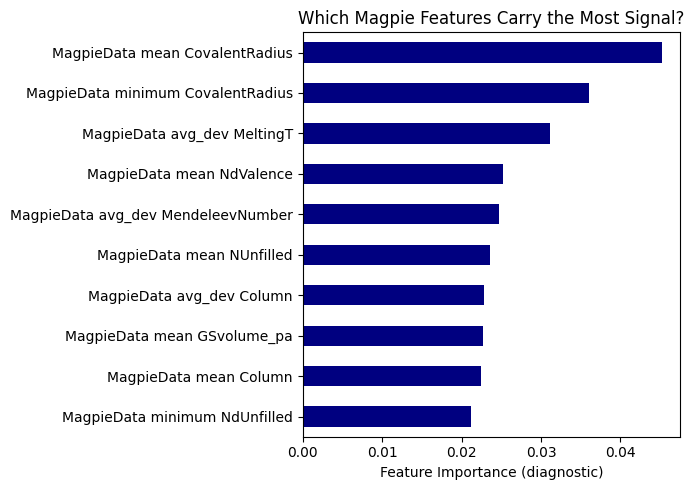

In [17]:
plt.figure(figsize=(7, 5))
importances.head(10).sort_values().plot(kind='barh', color='navy')
plt.xlabel("Feature Importance (diagnostic)")
plt.title("Which Magpie Features Carry the Most Signal?")
plt.tight_layout()
plt.show()


**Worth noticing:** several top features relate to valence electrons (`NdValence`, `NValence`, `NUnfilled`). This isn't a coincidence – valence electron concentration (VEC) is a well-known empirical rule real metallurgists already use to predict HEA phase formation (roughly: low VEC favors BCC, high VEC favors FCC). Our purely data-driven feature ranking independently rediscovered a physically meaningful signal that domain scientists already knew about – a reassuring sign the features are capturing something real, not noise.

---
## Quick Check 3

Why is it reassuring that the top data-driven features relate to valence electron count, a quantity metallurgists already use empirically?

**(i)  It proves Random Forest is the best possible classifier for this problem**

**(ii)  It suggests the engineered features are capturing physically meaningful signal, not just fitting noise – independent confirmation from domain knowledge**

**(iii)  It means Er and H should have been used instead**

*Think about it, then check the answer below.*

**Answer: (ii)** — when a purely statistical feature-importance ranking lines up with an independently-known physical rule, that's a strong, reassuring signal the features (and the data) are sound – the same kind of sanity check we used in Session 1 of the clustering topic ('does this match domain knowledge?').

## Step 7 — Before the Machines: What Metallurgists Already Knew

Long before `matminer` or Random Forest, metallurgists had their own empirical rules for predicting whether a multi-principal-element alloy would form a simple solid solution — and if so, whether it would be FCC or BCC. Two of the best-established:

- **Atomic size mismatch, δ** (Zhang et al., *Adv. Eng. Mater.*, 2008) — solid solutions are expected when δ ≤ 6.6%
- **Valence electron concentration, VEC** (Guo et al., *J. Appl. Phys.*, 2011) — VEC ≥ 8.00 favors FCC, VEC < 6.87 favors BCC

Let's compute these ourselves for our familiar **Al0.5 Co1 Fe1 Ni1** example, then check the rule against the *entire* 1,545-alloy dataset.

In [18]:
from pymatgen.core import Element

# Atomic size mismatch (delta) -- Zhang et al. 2008
r_bar = sum(fractions[el] * Element(el).atomic_radius for el in fractions)
delta = 100 * np.sqrt(sum(fractions[el] * (1 - Element(el).atomic_radius / r_bar)**2 for el in fractions))

print(f"Atomic size mismatch (delta): {delta:.2f}%")
print(f"VEC -- already computed in Step 4 as 'MagpieData mean NValence': "
      f"{feature_dict['MagpieData mean NValence']:.2f}")

Atomic size mismatch (delta): 3.43%
VEC -- already computed in Step 4 as 'MagpieData mean NValence': 8.14


**Both criteria point the same way for this alloy:** δ = 3.43% is well under the 6.6% solid-solution threshold, and VEC = 8.14 sits above the 8.00 FCC threshold — both predict a single FCC solid solution, consistent with the well-documented tendency of low-Al AlCoFeNi-type alloys to form FCC.

---
## Now Check the Rule Against All 1,545 Alloys

Let's see how well this 2011-era, two-parameter rule holds up against a much larger, more diverse dataset it was never calibrated on.

In [19]:
from pymatgen.core import Element

# Standard VEC table (Guo & Liu, 2011) -- group valence electron counts
vec_table = {
    'Sc': 3, 'Y': 3, 'Ti': 4, 'Zr': 4, 'Hf': 4, 'V': 5, 'Nb': 5, 'Ta': 5,
    'Cr': 6, 'Mo': 6, 'W': 6, 'Mn': 7, 'Re': 7, 'Fe': 8, 'Co': 9, 'Ni': 10,
    'Cu': 11, 'Ag': 11, 'Pd': 10, 'Zn': 12, 'Al': 3, 'Si': 4, 'Ga': 3,
    'Sn': 4, 'Mg': 2, 'Ca': 2, 'Li': 1, 'B': 3, 'C': 4, 'Nd': 3
}

def compute_delta(formula):
    c = Composition(formula)
    f = c.fractional_composition.as_dict()
    rb = sum(f[el] * Element(el).atomic_radius for el in f)
    return 100 * np.sqrt(sum(f[el] * (1 - Element(el).atomic_radius / rb)**2 for el in f))

def compute_vec(formula):
    c = Composition(formula)
    f = c.fractional_composition.as_dict()
    return sum(f[el] * vec_table[el] for el in f)

df_featurized['delta'] = df_featurized['FORMULA'].apply(compute_delta)
df_featurized['VEC_manual'] = df_featurized['FORMULA'].apply(compute_vec)

def predict_phase(vec):
    if vec >= 8.0:
        return 'FCC'
    elif vec < 6.87:
        return 'BCC'
    return 'other'

df_featurized['predicted_phase'] = df_featurized['VEC_manual'].apply(predict_phase)
agreement = (df_featurized['predicted_phase'] == df_featurized['PROPERTY: BCC/FCC/other']).mean()

print(f"Overall agreement, 2011 VEC rule vs. actual labels: {agreement*100:.1f}%")
print(f"Alloys satisfying delta <= 6.6% (solid-solution criterion): "
      f"{(df_featurized['delta'] <= 6.6).mean()*100:.1f}%")
pd.crosstab(df_featurized['PROPERTY: BCC/FCC/other'], df_featurized['predicted_phase'])

Overall agreement, 2011 VEC rule vs. actual labels: 61.7%
Alloys satisfying delta <= 6.6% (solid-solution criterion): 92.1%


predicted_phase,BCC,FCC,other
PROPERTY: BCC/FCC/other,,,
BCC,431,1,36
FCC,4,203,58
other,347,145,320


**~62% overall agreement** — strong on the pure BCC and FCC alloys (the diagonal), but weak on `other` (mixed/complex phases). That's not the rule being wrong — it's the rule being asked a question it was never designed to answer. VEC was calibrated to separate single-phase FCC from single-phase BCC solid solutions; it was never meant to anticipate the mixed and complex phases that make up a large share of this modern, more diverse dataset.

Notice also that **92% of alloys satisfy δ ≤ 6.6%** — the size-mismatch criterion barely discriminates here, since researchers rarely publish an alloy so size-mismatched it wouldn't form *any* solid solution. In practice, almost all of the predictive power above comes from VEC alone.

This is exactly *why* Step 6's automated approach matters: Random Forest's data-driven feature ranking independently rediscovered valence-electron-related features as important — but it also had access to 131 other automatically-generated descriptors that a two-parameter 2011 rule never could. Domain knowledge and automated feature engineering aren't competitors here; the second builds on and extends the first.

*(A third classic parameter, **Ω** — combining mixing entropy, mixing enthalpy, and average melting point, with a solid-solution threshold of Ω ≥ 1.1 — is defined in the same literature. Computing it properly requires binary mixing-enthalpy data from the Miedema model, which is beyond this session's scope, but the same logic applies: it's another hand-built physical parameter this dataset's automated features effectively subsume.)*

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions on the TRAINING data (this is diagnostic only)
y_pred = diagnostic_rf.predict(X)

# Overall accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Random Forest Training Accuracy: {accuracy:.3f}")
print()

# Per-class metrics
print("Per-class performance:")
print(classification_report(y, y_pred, target_names=['BCC', 'FCC', 'other']))
print()

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y, y_pred, labels=['BCC', 'FCC', 'other'])
print(pd.DataFrame(cm, 
                   index=['True BCC', 'True FCC', 'True other'],
                   columns=['Pred BCC', 'Pred FCC', 'Pred other']))


Random Forest Training Accuracy: 0.946

Per-class performance:
              precision    recall  f1-score   support

         BCC       0.96      0.96      0.96       468
         FCC       0.92      0.90      0.91       265
       other       0.94      0.95      0.95       812

    accuracy                           0.95      1545
   macro avg       0.94      0.94      0.94      1545
weighted avg       0.95      0.95      0.95      1545


Confusion Matrix:
            Pred BCC  Pred FCC  Pred other
True BCC         449         0          19
True FCC           0       239          26
True other        17        22         773


In [23]:
## Step 6b [Optional] — Quick Sanity Check: Does the RF Model Work?

# Remember: proper model evaluation (train/test split, cross-validation) 
# is covered in the Day 2 classification sessions. This is just a 
# diagnostic check that our features aren't garbage.

y_pred = diagnostic_rf.predict(X)
accuracy = accuracy_score(y, y_pred)

print(f"Training accuracy (all data, diagnostic only): {accuracy:.1%}")
print(f"Baseline (always predict 'other'): {(y == 'other').mean():.1%}")
print()
print("✓ RF beats the baseline, suggesting features carry predictive signal")
print("✓ Full evaluation with proper train/test splits comes in Day 2")


Training accuracy (all data, diagnostic only): 94.6%
Baseline (always predict 'other'): 52.6%

✓ RF beats the baseline, suggesting features carry predictive signal
✓ Full evaluation with proper train/test splits comes in Day 2


---
## Quick Check 4

The 2011 VEC rule agrees well with actual labels for pure BCC and FCC alloys, but poorly for `other` (mixed/complex) phases. What does this best suggest?

**(i)  VEC has no real physical meaning and the agreement on BCC/FCC was a coincidence**

**(ii)  The rule was calibrated on simpler solid-solution-forming alloys; mixed/complex phases involve additional physics a single electron-count threshold was never designed to capture**

**(iii)  The dataset's phase labels for `other` alloys are unreliable**

*Think about it, then check the answer below.*

**Answer: (ii)** — VEC is a genuinely useful, physically-grounded parameter (as the strong BCC/FCC agreement shows), but it was derived from a narrower set of alloys that mostly did form clean single-phase solid solutions. A modern, more diverse dataset naturally includes alloys and phase outcomes the original rule never had to account for — which is precisely the gap automated, many-feature approaches are built to close.

## Step 8 — Save the Featurized Dataset

This properly featurized dataset – 132 numeric descriptors per alloy, plus the true phase label – is now ready for the classification sessions that follow.

In [20]:
output_cols = ['FORMULA', 'PROPERTY: BCC/FCC/other'] + feature_cols
df_featurized[output_cols].to_csv('MPEA_featurized.csv', index=False)
print("Saved MPEA_featurized.csv:", df_featurized[output_cols].shape)


Saved MPEA_featurized.csv: (1545, 134)


## Wrap-Up

- Raw composition (a formula string) can't be used directly by any ML model – it has to become a fixed-length numeric vector first
- Magpie descriptors solve this generally: tabulated per-element properties, aggregated via mean/min/max/range/mode/avg_dev, regardless of how many elements are in the alloy
- We verified `matminer`'s automation against a hand-computed example – exact match
- Not every one of the 132 generated features is equally useful – a quick diagnostic check showed valence-electron-related features ranking highest, independently matching known metallurgical intuition
- Classic hand-built rules (atomic size mismatch δ, valence electron concentration VEC) predate automated feature engineering entirely — they agree well on simple BCC/FCC alloys (~62% overall) but can't capture the mixed/complex phases a modern, diverse dataset contains, motivating the richer automated approach
- The featurized dataset is now saved and ready

**Next: logistic regression and Random Forest, each in their own dedicated session, using this exact featurized dataset.**